# Titanic data science project
https://www.kaggle.com/c/titanic


In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
from os import path

train_path = path.join('datasets', 'titanic', 'train.csv')
test_path = path.join('datasets', 'titanic', 'test.csv')

In [91]:
train_data = pd.read_csv(train_path)
display(train_data.sample(10))

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
363,364,0,3,"Asim, Mr. Adola",male,35.0,0,0,SOTON/O.Q. 3101310,7.0500,NaN,S
683,684,0,3,"Goodwin, Mr. Charles Edward",male,14.0,5,2,CA 2144,46.9000,NaN,S
790,791,0,3,"Keane, Mr. Andrew ""Andy""",male,NaN,0,0,12460,7.7500,NaN,Q
192,193,1,3,"Andersen-Jensen, Miss. Carla Christine Nielsine",female,19.0,1,0,350046,7.8542,NaN,S
719,720,0,3,"Johnson, Mr. Malkolm Joackim",male,33.0,0,0,347062,7.7750,NaN,S
725,726,0,3,"Oreskovic, Mr. Luka",male,20.0,0,0,315094,8.6625,NaN,S
840,841,0,3,"Alhomaki, Mr. Ilmari Rudolf",male,20.0,0,0,SOTON/O2 3101287,7.9250,NaN,S
539,540,1,1,"Frolicher, Miss. Hedwig Margaritha",female,22.0,0,2,13568,49.5000,B39,C
101,102,0,3,"Petroff, Mr. Pastcho (""Pentcho"")",male,NaN,0,0,349215,7.8958,NaN,S
347,348,1,3,"Davison, Mrs. Thomas Henry (Mary E Finck)",female,NaN,1,0,386525,16.1000,NaN,S


In [92]:
test_data = pd.read_csv(test_path)
display(test_data.head())

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [93]:
print(f"Train data shape: {train_data.shape}, Test data shape: {test_data.shape}")
display(train_data.describe(include='all'))
print(train_data.info())

Train data shape: (891, 12), Test data shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None


<Axes: xlabel='Embarked', ylabel='Survived'>

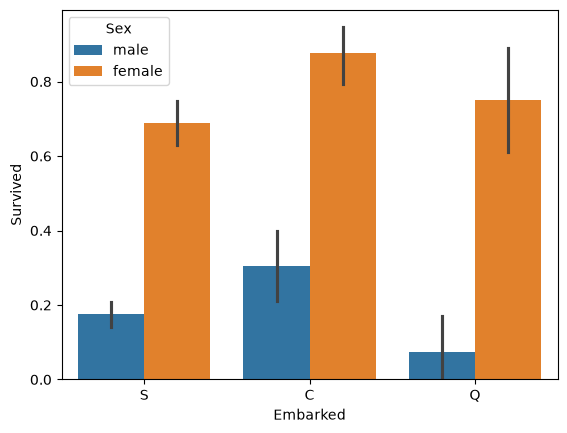

In [94]:
sns.barplot(x='Embarked', y='Survived', hue='Sex', data=train_data)

<Axes: xlabel='Pclass', ylabel='Survived'>

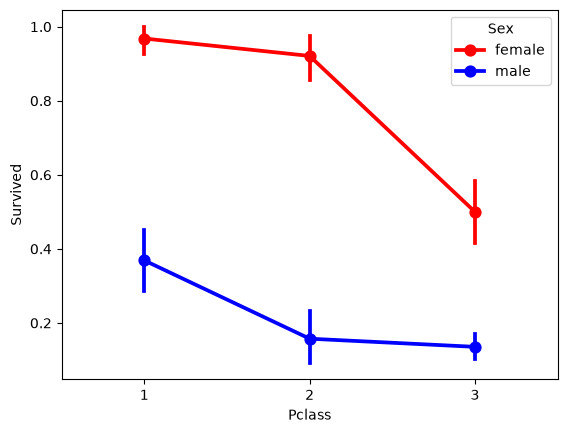

In [95]:
sns.pointplot(x='Pclass', y='Survived', hue='Sex', palette={'male': 'blue', 'female': 'red'}, data=train_data)

array([[<Axes: title={'center': 'Age'}>]], dtype=object)

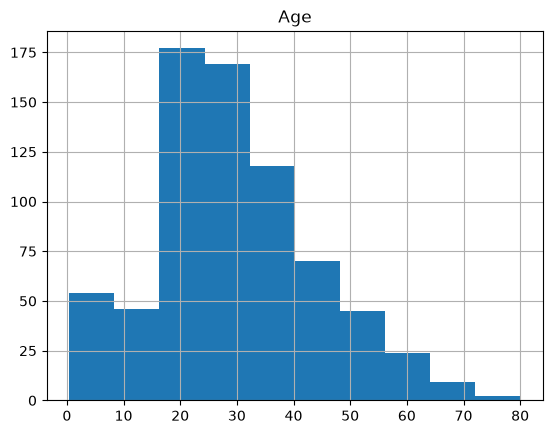

In [96]:
train_data.hist(column='Age')

In [97]:
# Function to categorize age into different age groups
def cat_age(data):
  data['Age'] = data['Age'].fillna(-0.5)
  bins = [-1, 0, 5, 12, 18, 25, 35, 60, 120]
  labels = ['Missing', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Senior']
  data['Age'] = pd.cut(data['Age'], bins=bins, labels=labels)
  return

In [98]:
cat_age(train_data)
cat_age(test_data)

train_data['Age'].sample(10)

460          Adult
108          Adult
788           Baby
202    Young Adult
845          Adult
4      Young Adult
0          Student
101        Missing
882        Student
539        Student
Name: Age, dtype: category
Categories (8, str): ['Missing' < 'Baby' < 'Child' < 'Teenager' < 'Student' < 'Young Adult' < 'Adult' < 'Senior']

<Axes: xlabel='Cabin', ylabel='count'>

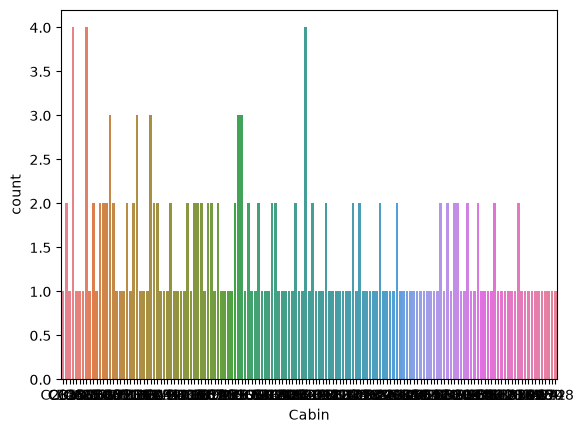

In [99]:
sns.countplot(x='Cabin', data=train_data, hue='Cabin', legend=False)

In [100]:
train_data['Cabin'].sample(10)

516        F33
243        NaN
873        NaN
340         F2
639        NaN
469        NaN
97     D10 D12
121        NaN
668        NaN
91         NaN
Name: Cabin, dtype: str

In [101]:
# Function to extract the deck information from the cabin column
def extract_cabin(data):
  data['Cabin'] = data['Cabin'].fillna('N')
  # Extract the first letter of the cabin to represent the deck
  data['Cabin'] = data['Cabin'].apply(lambda x: x[0])
  return

In [102]:
extract_cabin(train_data)
extract_cabin(test_data)

train_data['Cabin'].sample(10)

878    N
502    N
602    N
511    N
599    A
816    N
518    N
753    N
461    N
589    N
Name: Cabin, dtype: str

In [103]:
train_data['Fare'].sample(10)

744      7.9250
178     13.0000
773      7.2250
799     24.1500
103      8.6542
844      8.6625
96      34.6542
436     34.3750
737    512.3292
887     30.0000
Name: Fare, dtype: float64

In [104]:
# Function to categorize the fare into quantile-based bins
def cat_fare(data):
  data['Fare'] = data['Fare'].fillna(0.0)
  # Categorize the fare into bins
  cat_names = ['1st', '2nd', '3rd', '4th', '5th']
  data['Fare'] = pd.qcut(data['Fare'], q=5, labels=cat_names)
  return

In [105]:
cat_fare(train_data)
cat_fare(test_data)

train_data['Fare'].sample(10)

256    5th
185    5th
546    4th
146    1st
301    4th
873    2nd
166    5th
882    3rd
212    1st
126    1st
Name: Fare, dtype: category
Categories (5, str): ['1st' < '2nd' < '3rd' < '4th' < '5th']

In [106]:
train_data['Name'].sample(10)

723                  Hodges, Mr. Henry Price
842                  Serepeca, Miss. Augusta
516             Lemore, Mrs. (Amelia Milley)
145             Nicholls, Mr. Joseph Charles
445                Dodge, Master. Washington
732                     Knight, Mr. Robert J
832                           Saad, Mr. Amin
259              Parrish, Mrs. (Lutie Davis)
246    Lindahl, Miss. Agda Thorilda Viktoria
224             Hoyt, Mr. Frederick Maxfield
Name: Name, dtype: str

In [107]:
def extract_title(data):
  data['Title'] = data['Name'].apply(lambda x: x.split()[1])
  return

In [108]:
extract_title(train_data)
extract_title(test_data)

train_data['Title'].sample(10)

184      Miss.
824    Master.
666        Mr.
277        Mr.
782        Mr.
181        Mr.
144        Mr.
723        Mr.
605        Mr.
150       Rev.
Name: Title, dtype: str

In [109]:
train_data.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title
199,200,0,2,"Yrois, Miss. Henriette (""Mrs Harbeck"")",female,Student,0,0,248747,3rd,N,S,Miss.
374,375,0,3,"Palsson, Miss. Stina Viola",female,Baby,3,1,349909,3rd,N,S,Miss.
111,112,0,3,"Zabour, Miss. Hileni",female,Teenager,1,0,2665,3rd,N,C,Miss.
842,843,1,1,"Serepeca, Miss. Augusta",female,Young Adult,0,0,113798,4th,N,C,Miss.
145,146,0,2,"Nicholls, Mr. Joseph Charles",male,Student,1,1,C.A. 33112,4th,N,S,Mr.
72,73,0,2,"Hood, Mr. Ambrose Jr",male,Student,0,0,S.O.C. 14879,5th,N,S,Mr.
376,377,1,3,"Landergren, Miss. Aurora Adelia",female,Student,0,0,C 7077,1st,N,S,Miss.
370,371,1,1,"Harder, Mr. George Achilles",male,Student,1,0,11765,5th,E,C,Mr.
803,804,1,3,"Thomas, Master. Assad Alexander",male,Baby,0,1,2625,2nd,N,C,Master.
192,193,1,3,"Andersen-Jensen, Miss. Carla Christine Nielsine",female,Student,1,0,350046,1st,N,S,Miss.


In [110]:
def drop_columns(data, columns):
  data.drop(columns, axis=1, inplace=True)

In [111]:
columns_to_drop = ['Name', 'Ticket', 'Embarked']
drop_columns(train_data, columns_to_drop)
drop_columns(test_data, columns_to_drop)

train_data.sample(10)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
674,675,0,2,male,Missing,0,0,1st,N,Mr.
317,318,0,2,male,Adult,0,0,3rd,N,Dr.
284,285,0,1,male,Missing,0,0,4th,A,Mr.
566,567,0,3,male,Student,0,0,2nd,N,Mr.
55,56,1,1,male,Missing,0,0,4th,C,Mr.
288,289,1,2,male,Adult,0,0,3rd,N,Mr.
672,673,0,2,male,Senior,0,0,2nd,N,Mr.
889,890,1,1,male,Young Adult,0,0,4th,C,Mr.
626,627,0,2,male,Adult,0,0,3rd,N,Rev.
332,333,0,1,male,Adult,0,1,5th,C,Mr.


<Axes: xlabel='Age', ylabel='Survived'>

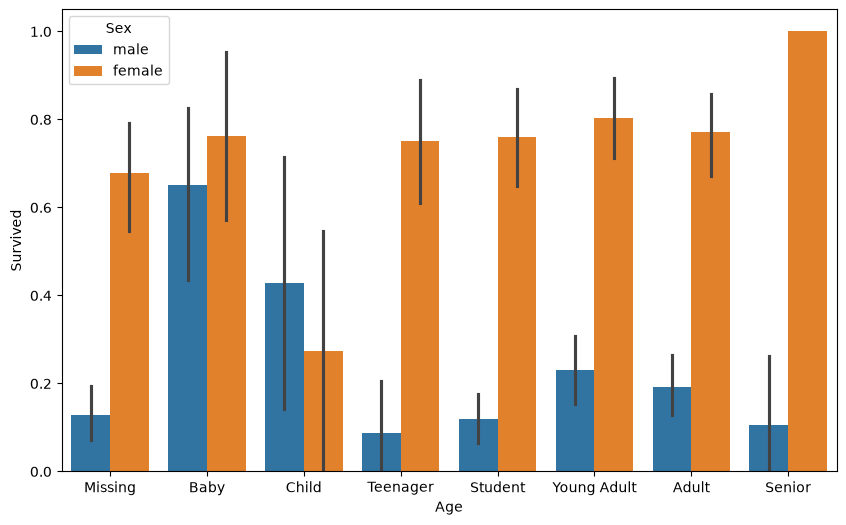

In [117]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Age', y='Survived', hue='Sex', data=train_data, ax=ax)

<Axes: xlabel='Fare', ylabel='Survived'>

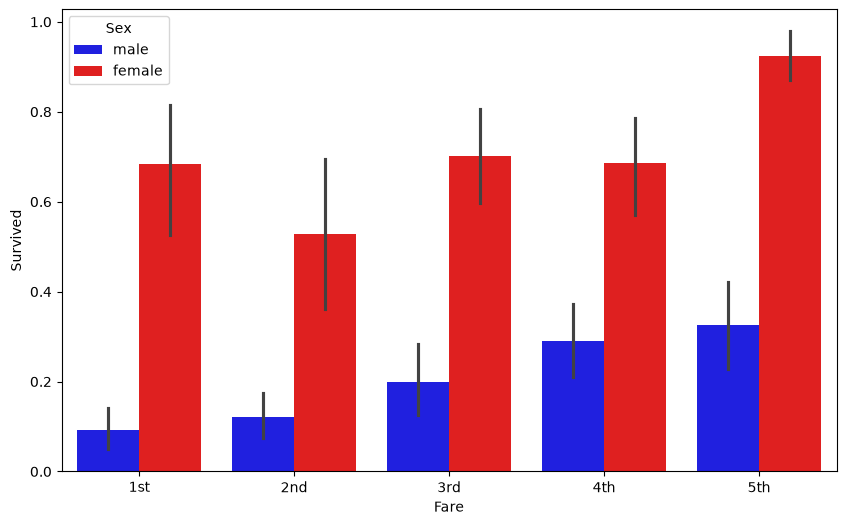

In [121]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='Fare', y='Survived', hue='Sex', palette={'male': 'blue', 'female': 'red'}, data=train_data, ax=ax)

In [122]:
from sklearn import preprocessing

In [136]:
# Function to encode categorical features using LabelEncoder from sklearn
def encode_features(df_train, df_test, features):
  df_combined = pd.concat([df_train[features], df_test[features]], axis=0)
  for feature in features:
    # Initialize the LabelEncoder for the current feature
    le = preprocessing.LabelEncoder()
    le = le.fit(df_combined[feature])
    # Transform the training and test data using the fitted LabelEncoder
    df_train[feature] = le.transform(df_train[feature])
    df_test[feature] = le.transform(df_test[feature])

In [140]:
features = ['Sex', 'Age', 'Fare', 'Cabin', 'Title']
encode_features(train_data, test_data, features)
train_data.sample(5)

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
268,269,1,1,0,0,0,1,4,2,20
29,30,0,3,1,3,0,0,1,7,19
810,811,0,3,1,7,0,0,1,7,19
114,115,0,3,0,6,0,0,2,7,16
540,541,1,1,0,0,0,2,4,1,16


In [ ]:
from sklearn.model_selection import train_test_split

In [146]:
# Separate features and target variable from the training data
X= train_data.drop('Survived', axis=1) # Features (independent variables)
Y= train_data['Survived'] # Independent variable (target)

# Split the data into training and validation sets
validation_size = 0.15
# Set the random seed for reproducibility
seed = np.random.randint(1000)
# Perform the train-test split. Return 4 datasets: X_train, X_val, Y_train, Y_val
X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=validation_size, random_state=seed)

display(X_train.sample(5), Y_train.sample(5))
display(X_val.sample(5), Y_val.sample(5))

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
787,788,3,1,2,4,1,3,7,13
728,729,2,1,5,1,0,3,7,19
308,309,2,1,7,1,0,3,7,19
530,531,2,0,1,1,1,3,7,16
691,692,3,0,1,0,1,2,7,16


861    0
701    1
329    1
733    0
485    0
Name: Survived, dtype: int64

,PassengerId,Pclass,Sex,Age,SibSp,Parch,Fare,Cabin,Title
524,525,3,1,3,0,0,0,7,19
686,687,3,1,6,4,1,3,7,19
723,724,2,1,0,0,0,2,7,19
652,653,3,1,5,0,0,1,7,19
202,203,3,1,7,0,0,0,7,19


257    1
13     0
292    0
0      0
220    1
Name: Survived, dtype: int64